<a href="https://colab.research.google.com/github/sunceet/lab6-app/blob/main/3_lab_analys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

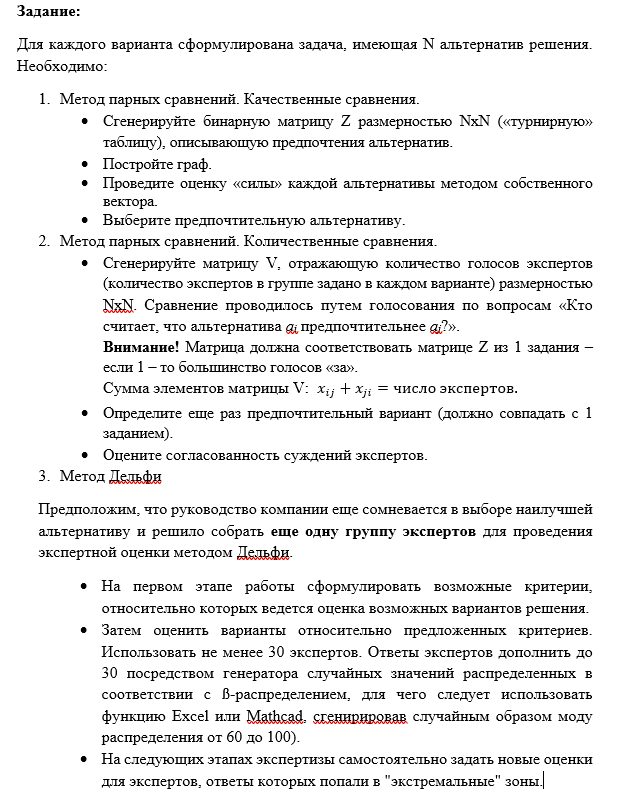

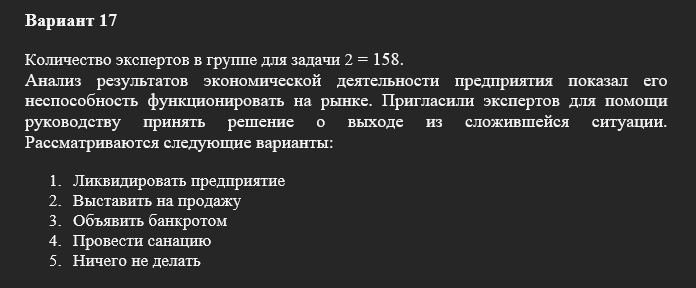

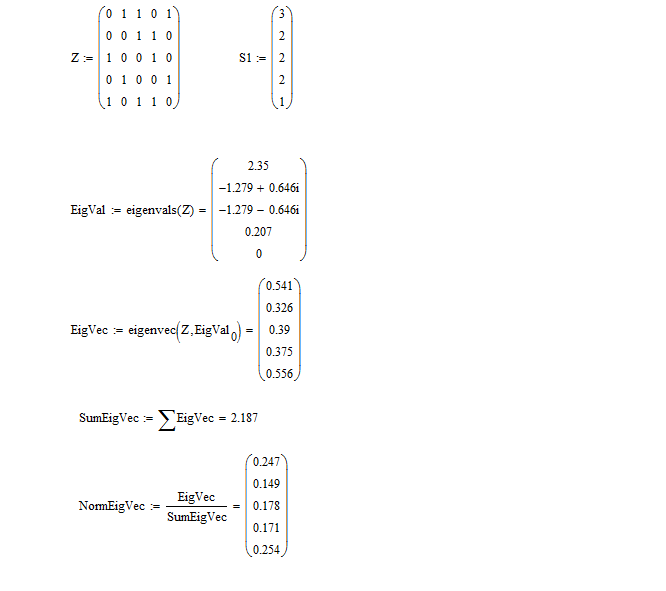

По сумме единиц в строках матрицы Z видно, что наибольшее количество прямых связей имеет 1-ый и 5-ый элемент. Однако более корректная оценка влияния определяется не только числом связей, но и их структурой в системе. Для этого был использован собственный вектор матрицы. Нормированный собственный вектор имеет вид: 0.247 0.149 0.178 0.171 0.254


Это означает, что:

    1-й элемент (0.247)
    2-й элемент (0.149)
    4-й элемент (0.178)
    3-й элемент (0.171)
    5-й элемент (0.254)


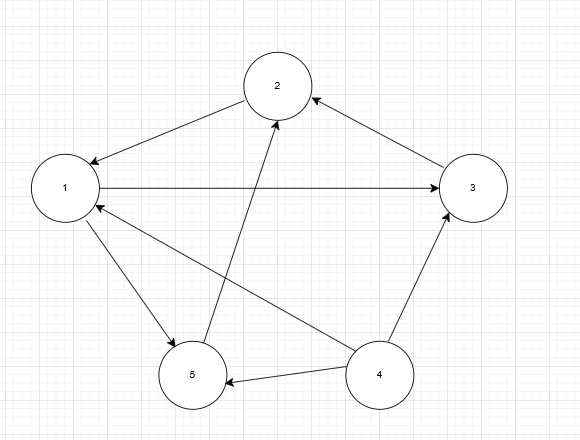

In [ ]:
import numpy as np

Z = np.array([
[0, 1, 1, 0, 1],
[0, 0, 1, 1, 0],
[1, 0, 0, 1, 0],
[0, 1, 0, 0, 1],
[1, 0, 1, 1, 0]
],)

print("Матрица Z:")
print(Z)

S1 = np.sum(Z, axis=1)
print("\nS1 =", S1)

eig_vals, eig_vecs = np.linalg.eig(Z)

print("\nEigVal =", np.round(eig_vals, 3))

index_max = np.argmax(eig_vals.real)
EigVec = eig_vecs[:, index_max].real

print("\nEigVec =", np.round(EigVec, 3))

SumEigVec = np.sum(EigVec)
NormEigVec = EigVec / SumEigVec

print("\nSumEigVec =", round(SumEigVec, 3))
print("\nNormEigVec =", np.round(NormEigVec, 3))

Матрица Z:
[[0 1 1 0 1]
 [0 0 1 1 0]
 [1 0 0 1 0]
 [0 1 0 0 1]
 [1 0 1 1 0]]

S1 = [3 2 2 2 3]

EigVal = [ 2.35 +0.j    -1.279+0.646j -1.279-0.646j  0.207+0.j     0.   +0.j   ]

EigVec = [-0.541 -0.326 -0.39  -0.375 -0.556]

SumEigVec = -2.187

NormEigVec = [0.247 0.149 0.178 0.171 0.254]


Первый метод был реализован на Python для проверки вычислений. Полученные результаты полностью совпали с ручными расчётами, что подтверждает корректность определения структуры влияний и приоритетов элементов.

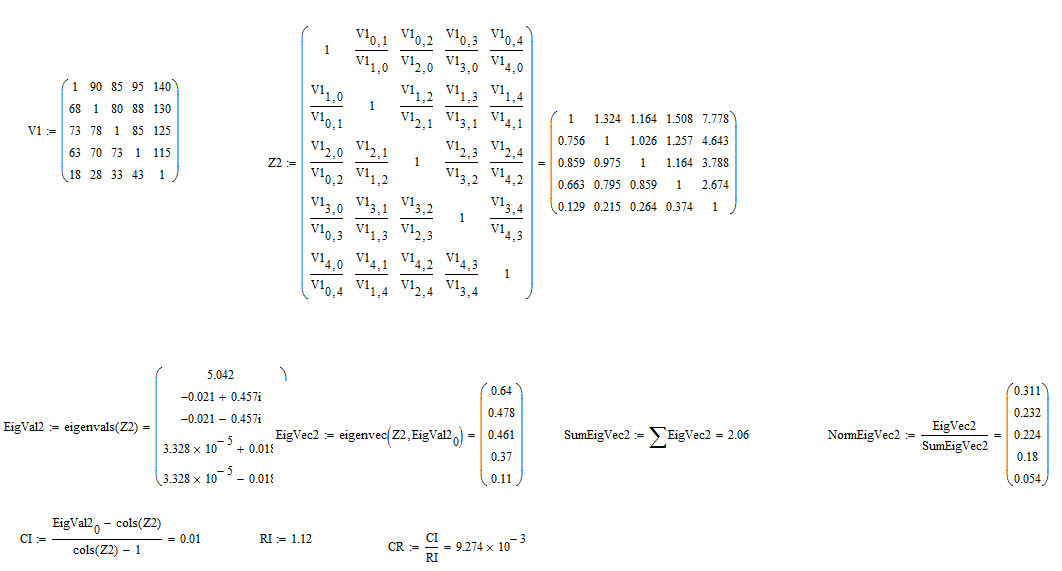

На основе матрицы парных сравнений была построена нормализованная матрица Z2, после чего определён вектор приоритетов альтернатив. Нормированный собственный вектор имеет вид:

(0.311; 0.232; 0.224; 0.180, 0,054)

Полученные значения показывают следующий порядок приоритетов:

    1-я альтернатива - 0.311
    2-я альтернатива - 0.232
    4-я альтернатива - 0.224
    3-я альтернатива - 0.180
    5-я альтернатива - 0.054

Таким образом, наиболее предпочтительной является 1-я альтернатива, а наименее предпочтительной - 5-я.

Дополнительно была проверена согласованность суждений. Получено:

    индекс согласованности CI=0.01
    отношение согласованности CR=9.274х10^-3



In [ ]:
import numpy as np

V1 = np.array([
   [1, 90, 85, 95, 140],
   [68, 1, 80, 88, 130],
   [73, 78, 1, 85, 125],
   [63, 70, 73, 1, 115],
   [18, 25, 33, 43, 1]
], dtype=float)

print("V1 =")
print(V1)

n = len(V1)
Z2 = np.zeros((n, n))

for i in range(n):
   for j in range(n):
       if i == j:
           Z2[i, j] = 1
       else:
           Z2[i, j] = V1[i, j] / V1[j, i]

print("\nZ2 =")
print(np.round(Z2, 3))

EigVal2, EigVecMatrix2 = np.linalg.eig(Z2)

print("\nEigVal2 =", np.round(EigVal2, 3))

index_max = np.argmax(EigVal2.real)
EigVec2 = EigVecMatrix2[:, index_max].real

if np.sum(EigVec2) < 0:
   EigVec2 = -EigVec2

print("\nEigVec2 =", np.round(EigVec2, 3))

SumEigVec2 = np.sum(EigVec2)
print("\nSumEigVec2 =", round(SumEigVec2, 3))

NormEigVec2 = EigVec2 / SumEigVec2
print("\nNormEigVec2 =", np.round(NormEigVec2, 3))

CI = (EigVal2[index_max].real - n) / (n - 1)
RI = 1.12
CR = CI / RI

print("\nCI =", round(CI, 3))
print("\nRI =", RI)
print("\nCR =", round(CR, 3))

V1 =
[[  1.  90.  85.  95. 140.]
 [ 68.   1.  80.  88. 130.]
 [ 73.  78.   1.  85. 125.]
 [ 63.  70.  73.   1. 115.]
 [ 18.  25.  33.  43.   1.]]

Z2 =
[[1.    1.324 1.164 1.508 7.778]
 [0.756 1.    1.026 1.257 5.2  ]
 [0.859 0.975 1.    1.164 3.788]
 [0.663 0.795 0.859 1.    2.674]
 [0.129 0.192 0.264 0.374 1.   ]]

EigVal2 = [ 5.045e+00+0.j    -2.200e-02+0.478j -2.200e-02-0.478j -1.000e-03+0.029j
 -1.000e-03-0.029j]

EigVec2 = [0.636 0.488 0.459 0.369 0.107]

SumEigVec2 = 2.058

NormEigVec2 = [0.309 0.237 0.223 0.179 0.052]

CI = 0.011

RI = 1.12

CR = 0.01


In [ ]:
import numpy as np
import pandas as pd
import random

np.random.seed(42)
random.seed(42)

# Альтернативы для задачи 2
alternatives = [
    "Ликвидировать предприятие",
    "Выставить на продажу",
    "Объявить банкротом",
    "Провести санацию",
    "Ничего не делать"
]

# Критерии для оценки альтернатив
criteria = [
    "Срок реализации решения",
    "Финансовые затраты",
    "Социальные последствия",
    "Риск для бизнеса",
    "Влияние на репутацию"
]

# Веса критериев (можно скорректировать по значимости)
weights = np.array([0.25, 0.30, 0.15, 0.20, 0.10])

# Количество экспертов
TARGET_EXPERTS = 158

N = len(alternatives)
C = len(criteria)

# Генерация экспертных оценок через beta-распределение
def generate_beta_scores(n, mode_min=50, mode_max=100, k=15):
    mode = random.uniform(mode_min, mode_max)
    mode01 = mode / 100.0

    alpha = 1 + k * mode01
    beta = 1 + k * (1 - mode01)

    values = np.random.beta(alpha, beta, n)
    scores = np.round(values * 100, 2)
    return scores

# Генерация оценок
answers = np.zeros((TARGET_EXPERTS, N, C))

for a in range(N):
    for c in range(C):
        answers[:, a, c] = generate_beta_scores(TARGET_EXPERTS)

# Функция Delphi с подробным выводом
def delphi_method(data, max_rounds=3, verbose=True):
    current = data.copy()

    if verbose:
        print("Исходные оценки экспертов:")
        print(np.round(current, 2))

    for round_num in range(1, max_rounds + 1):
        mean_val = np.mean(current)
        median_val = np.median(current)
        std_val = np.std(current)
        var_coef = std_val / mean_val if mean_val != 0 else 0

        q1 = np.percentile(current, 25)
        q3 = np.percentile(current, 75)

        extreme_low = np.where(current < q1)[0]
        extreme_high = np.where(current > q3)[0]
        extreme = np.concatenate((extreme_low, extreme_high))

        if verbose:
            print(f"\nРаунд {round_num}")
            print("Среднее:", round(mean_val, 2))
            print("Медиана:", round(median_val, 2))
            print("Стандартное отклонение:", round(std_val, 2))
            print("Коэффициент вариации:", round(var_coef, 3))
            print("Q1:", round(q1, 2))
            print("Q3:", round(q3, 2))
            print("Экстремальные эксперты:", (extreme + 1) if len(extreme) > 0 else "нет")

        # Корректируем экстремальные оценки
        for i in extreme:
            current[i] = round((current[i] + median_val) / 2, 2)

        if verbose:
            print("Оценки после корректировки:")
            print(np.round(current, 2))

        # Если достигнута согласованность — остановка
        if var_coef <= 0.30:
            if verbose:
                print("Достигнута согласованность мнений экспертов.")
            break

    if verbose:
        print("\nИтоговая медиана после Delphi:", round(np.median(current), 2))

    return current

# Применяем Delphi для всех альтернатив и критериев
final_answers = np.zeros_like(answers)

for a in range(N):
    print("\nАЛЬТЕРНАТИВА:", alternatives[a])

    for c in range(C):
        print("КРИТЕРИЙ:", criteria[c])
        final_answers[:, a, c] = delphi_method(answers[:, a, c], max_rounds=3, verbose=True)

# Итоговые оценки по критериям (медианы)
final_scores = pd.DataFrame(index=criteria, columns=alternatives)

for c in range(C):
    for a in range(N):
        final_scores.iloc[c, a] = np.median(final_answers[:, a, c])

final_scores = final_scores.astype(float).round(2)

print("\nИТОГОВЫЕ МЕДИАННЫЕ ОЦЕНКИ ПО КРИТЕРИЯМ")
print(final_scores)

# Интегральная оценка с весами
integral_scores = (final_scores.T * weights).sum(axis=1).round(2)

print("\nИнтегральные оценки альтернатив:")
print(integral_scores)

best_alternative = integral_scores.idxmax()
print("\nЛучшая альтернатива по методу Дельфи:")
print(best_alternative)


АЛЬТЕРНАТИВА: Ликвидировать предприятие
КРИТЕРИЙ: Срок реализации решения
Исходные оценки экспертов:
[82.61 80.4  79.66 71.74 93.66 70.79 86.46 75.62 79.22 87.9  91.04 70.01
 81.05 81.51 66.58 83.93 69.78 75.98 78.2  78.81 71.18 86.05 64.26 82.32
 74.97 80.22 80.49 70.84 79.07 78.4  76.2  74.83 81.13 68.45 56.33 75.64
 77.98 93.05 79.96 69.95 58.32 78.61 91.08 68.23 73.5  79.1  73.65 86.34
 82.88 65.98 80.   84.8  75.86 65.65 88.32 68.6  71.47 81.99 88.76 89.8
 73.27 88.7  75.18 77.19 47.39 78.   77.83 95.97 66.19 68.83 85.03 65.11
 76.52 74.   83.07 62.53 79.73 89.01 74.51 70.97 93.53 93.27 69.41 82.97
 92.56 73.1  85.62 67.88 80.6  80.68 78.21 83.3  76.03 84.26 81.87 53.61
 77.72 86.73 84.39 85.61 84.6  74.82 85.82 77.88 84.08 81.81 87.25 75.13
 80.24 74.91 91.23 91.5  72.93 63.67 69.63 52.36 87.27 54.23 66.97 78.97
 71.05 75.25 56.5  84.38 73.9  70.17 94.17 71.17 93.3  70.32 68.1  88.17
 70.05 84.05 87.45 86.17 73.72 80.82 82.16 55.68 79.22 86.79 88.34 86.03
 79.2  86.74 75.94 92.2